# Reading the M2HATS ISFS Zarr stores

This notebook opens the three ISFS Zarr stores on GDEX and runs one small analysis on all of them: the **wind speed at 14:00 local time (PDT) on every day of the campaign, at every tower in the 50-tower array**.

| Store | Rate | Sonic winds |
|---|---|---|
| `isfs_m2hats_qc_geo_tiltcor_5min.zarr` | 5-minute statistics | geographic, tilt corrected |
| `isfs_m2hats_qc_geo_highrate.zarr` | 20–60 Hz | geographic, not tilt corrected |
| `isfs_m2hats_qc_geo_tiltcor_highrate.zarr` | 20–60 Hz | geographic, tilt corrected |

The array sonics are all mounted at about 4 m (the surveyed height of each is in the `site_height` coordinate), so that is the height used here. For other heights, use the `/profile_t0` groups, which have a `height` dimension (0.5–28 m) instead of `site`.

In [53]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

GDEX = "/lustre/desc1/scratch/myasears/M2HATS/GDEX_datasets"
stores = {
    "5-min, tilt-corrected":     "isfs_m2hats_qc_geo_tiltcor_5min.zarr",
    "High-rate, geo":            "isfs_m2hats_qc_geo_highrate.zarr",
    "High-rate, tilt-corrected": "isfs_m2hats_qc_geo_tiltcor_highrate.zarr",
}

# Opening is lazy: only metadata is read until values are needed.
trees = {name: xr.open_datatree(f"{GDEX}/{path}", engine="zarr", chunks={})
         for name, path in stores.items()}

for name, tree in trees.items():
    print(f"{name}\n  {tree.attrs['title']}\n  groups: {[g for g in tree.groups if tree[g].has_data]}")

5-min, tilt-corrected
  M2HATS ISFS 5-Minute Surface Meteorology and Flux Products, Geographic Tilt-Corrected Winds (restructured)
  groups: ['/array/barometer', '/array/irga', '/array/sonic', '/array/trh', '/profile_t0/barometer', '/profile_t0/irga', '/profile_t0/sonic', '/profile_t0/trh', '/radiation/nr01', '/soils/heat_flux', '/soils/moisture', '/soils/temperature', '/soils/thermal_props']
High-rate, geo
  M2HATS ISFS High-Rate Surface Meteorology and Flux Products, Geographic Winds Without Tilt Correction (restructured)
  groups: ['/array/barometer_20hz', '/array/irga_60hz', '/array/sonic_30hz', '/array/sonic_50hz', '/array/sonic_60hz', '/array/trh_1hz', '/profile_t0/barometer_20hz', '/profile_t0/irga_60hz', '/profile_t0/sonic_60hz', '/profile_t0/trh_1hz']
High-rate, tilt-corrected
  M2HATS ISFS High-Rate Surface Meteorology and Flux Products, Geographic Tilt-Corrected Winds (restructured)
  groups: ['/array/barometer_20hz', '/array/irga_60hz', '/array/sonic_30hz', '/array/sonic_50

Each group is an ordinary `xarray.Dataset`. The high-rate sonics are split by sampling rate (`sonic_30hz`, `sonic_50hz`, `sonic_60hz`), each with a `sample_<rate>` dimension holding the sub-second samples within every 1-second `time` step. In the 5-minute store all 51 array sonics are in one `sonic` group.

In [2]:
trees["High-rate, tilt-corrected"]["/array/sonic_60hz"].ds

<xarray.DatasetView> Size: 175GB
Dimensions:                (site: 22, time: 5529600, sample_60: 60)
Coordinates:
  * site                   (site) object 176B 't0p' 't1' 't2' ... 't44' 't47'
  * time                   (time) datetime64[ns] 44MB 2023-07-23T00:00:00.500...
    csat_model_appendix_a  (site) <U12 1kB dask.array<chunksize=(22,), meta=np.ndarray>
    sample_offset          (sample_60) float64 480B dask.array<chunksize=(60,), meta=np.ndarray>
    site_height            (site) float64 176B dask.array<chunksize=(22,), meta=np.ndarray>
    site_lat               (site) float64 176B dask.array<chunksize=(22,), meta=np.ndarray>
    site_lon               (site) float64 176B dask.array<chunksize=(22,), meta=np.ndarray>
Dimensions without coordinates: sample_60
Data variables:
    sonic_diag_bits        (site, time, sample_60) float32 29GB dask.array<chunksize=(22, 3600, 60), meta=np.ndarray>
    sonic_qc_flag          (site, time, sample_60) float32 29GB dask.array<chunksize=(22, 3600, 60), meta=np.ndarray>
    sonic_temperature      (site, time, sample_60) float32 29GB dask.array<chunksize=(22, 3600, 60), meta=np.ndarray>
    valid                  (time) int8 6MB dask.array<chunksize=(3600,), meta=np.ndarray>
    wind_u                 (site, time, sample_60) float32 29GB dask.array<chunksize=(22, 3600, 60), meta=np.ndarray>
    wind_v                 (site, time, sample_60) float32 29GB dask.array<chunksize=(22, 3600, 60), meta=np.ndarray>
    wind_w                 (site, time, sample_60) float32 29GB dask.array<chunksize=(22, 3600, 60), meta=np.ndarray>
Attributes:
    subarray:          horizontal_50_tower
    instrument_class:  CSAT3A 3D sonic anemometer (60 Hz)
    Conventions:       CF-1.10

## Wind speed at 14:00 PDT

Times are UTC and mark the centre of each bin, so 14:00 PDT (21:00 UTC) to 14:05 is exactly one 5-minute bin, or 300 one-second steps in the high-rate stores. For a like-for-like comparison, the speed is computed the same way for every store: average `wind_u` and `wind_v` over those 5 minutes, then take the magnitude.

In [3]:
def daily_2pm_speed(ds):
    """Speed of the 5-min mean wind from 14:00 to 14:05 PDT, one value per day per site."""
    t = ds.indexes["time"]
    ds = ds[["wind_u", "wind_v"]].isel(time=np.flatnonzero((t.hour == 21) & (t.minute < 5)))
    ds = ds.mean([d for d in ds.dims if d.startswith("sample")])  # high-rate only: average sub-second samples
    ds = ds.resample(time="1D").mean()
    return np.hypot(ds.wind_u, ds.wind_v)

def array_speed(tree):
    """All array towers in one DataArray (joins the 30/50/60 Hz high-rate groups)."""
    if "/array/sonic" in tree.groups:
        return daily_2pm_speed(tree["/array/sonic"].ds)
    return xr.concat([daily_2pm_speed(tree[f"/array/sonic_{r}hz"].ds) for r in (30, 50, 60)], dim="site")

speed = {name: array_speed(tree) for name, tree in trees.items()}
sites = speed["5-min, tilt-corrected"].site                      # t0p, t1p, t1, t2 ... t49 (west to east)
speed = {name: s.reindex(site=sites).compute() for name, s in speed.items()}  # the high-rate reads take a few minutes

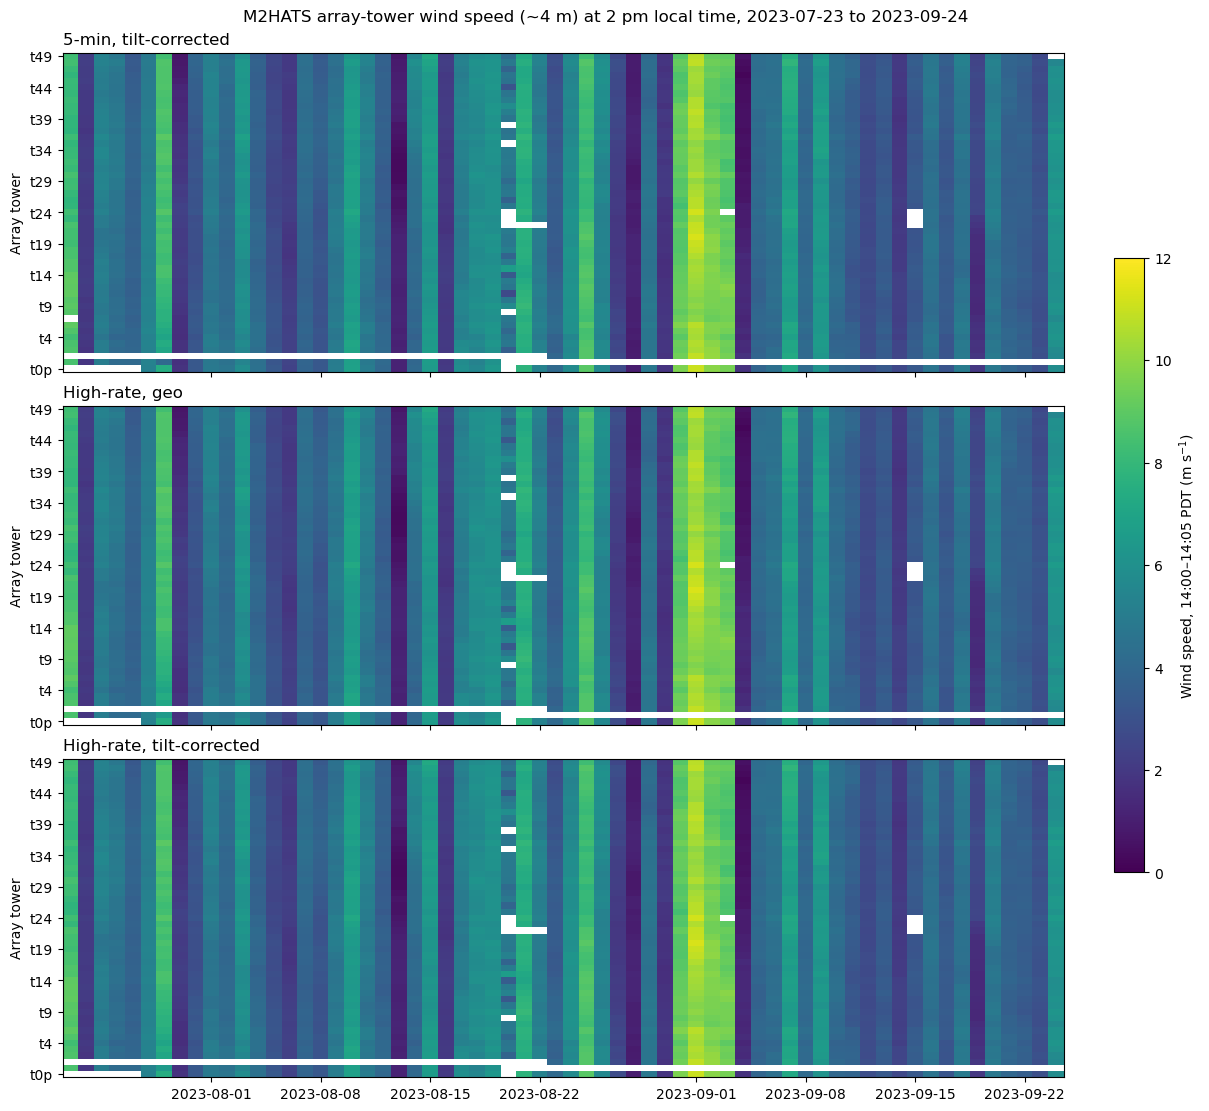

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True, layout="constrained")
for ax, (name, s) in zip(axes, speed.items()):
    im = ax.pcolormesh(s.time, np.arange(s.sizes["site"]), s.transpose("site", "time"),
                       vmin=0, vmax=12, shading="nearest")
    ax.set_yticks(np.arange(0, s.sizes["site"], 5), s.site.values[::5])
    ax.set_ylabel("Array tower")
    ax.set_title(name, loc="left")
fig.colorbar(im, ax=axes, label="Wind speed, 14:00–14:05 PDT (m s$^{-1}$)", shrink=0.6)
fig.suptitle("M2HATS array-tower wind speed (~4 m) at 2 pm local time, 2023-07-23 to 2023-09-24");

Blank cells are periods with no data, for example `t1p` (the CSAT3 at t1) after the 2023-08-23 sonic swap and `t1` (its CSAT3A replacement) before it.

## Do the stores agree?

The 5-minute store is computed from the tilt-corrected high-rate data, so the two agree closely. The points off the 1:1 line are mostly from windows where the high-rate data are only partly present (e.g. 2023-08-20); there the simple mean used here differs from the ISFS 5-minute statistic. Tilt correction mostly changes the vertical wind, so horizontal speed should differ only slightly between the geo and tilt-corrected high-rate stores.

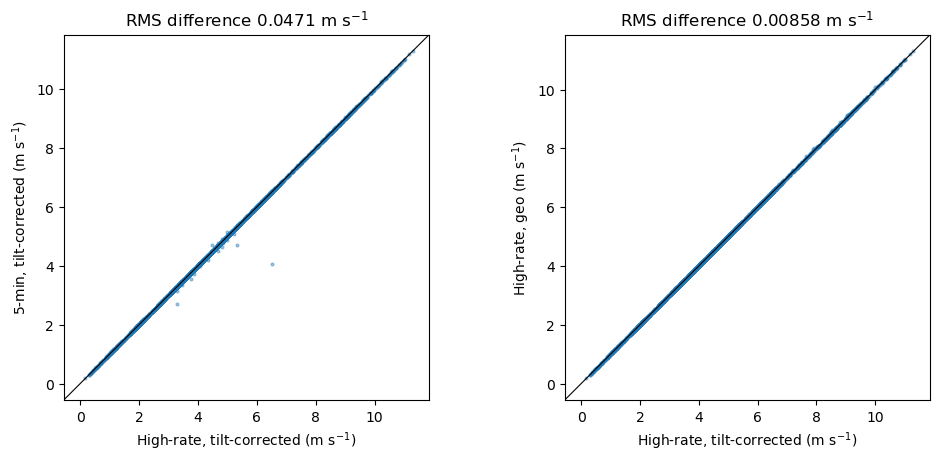

In [5]:
five, geo, tilt = speed.values()
pairs = [(tilt, five, "High-rate, tilt-corrected", "5-min, tilt-corrected"),
         (tilt, geo,  "High-rate, tilt-corrected", "High-rate, geo")]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), layout="constrained")
for ax, (x, y, xlabel, ylabel) in zip(axes, pairs):
    rms = float(np.sqrt(((y - x) ** 2).mean()))
    ax.scatter(x, y, s=4, alpha=0.4)
    ax.axline((0, 0), slope=1, color="k", lw=0.8)
    ax.set(xlabel=f"{xlabel} (m s$^{{-1}}$)", ylabel=f"{ylabel} (m s$^{{-1}}$)",
           title=f"RMS difference {rms:.3g} m s$^{{-1}}$", aspect="equal")